<a href="https://colab.research.google.com/github/fifaaworldcup/exoplanet-habitability-model/blob/main/exoplanet_habitability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Top 30 physically plausible anomalies:
                        pl_name  VAE_anomaly  ESI_equal      CDHS   SEPHI_simple    pl_rade   pl_dens    pl_insol   st_teff  pl_orbeccen
1114                MASCARA-1 b     0.750538   0.038197  0.131538   0.000000e+00  17.900742  0.272232  38711.5000   7490.00      0.00034
4942            NSVS 14256825 b     0.476687   0.252122  1.000000  7.283687e-103  12.300000  2.413793      9.6678  40000.00      0.12000
1343                   KOI-13 b     0.392269   0.053579  0.135812   0.000000e+00  16.948008  0.653358  25339.9010   7650.00      0.00064
907                    NY Vir b     0.347487   0.301795  0.807127   8.809662e-01  13.300000  0.310345      2.1780  32780.00      0.15000
769   2MASS J19383260+4603591 b     0.338170   0.159178  0.721216   0.000000e+00  13.400000  0.250454     33.2985  29564.00      0.33000
366                 V0391 Peg b     0.254495   0.000000  0.000000   3.264426e-95  13.100000  0.451906      9.3750  29300.00      0.00000
12

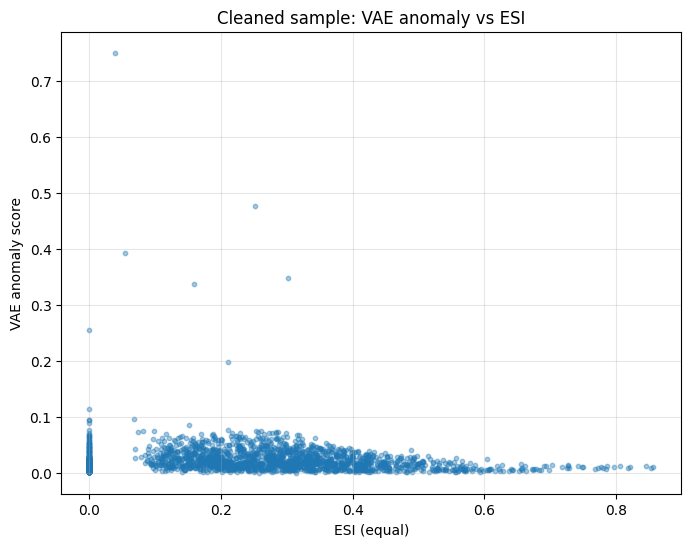

In [ ]:
# ===============================
#  REFINED ANOMALY RANKING – REMOVE UNPHYSICAL PLANETS
# ===============================
# Keep only plausible densities (0.1–10 Earth units) and radii (0.3–20 R_earth)
df_clean = df[
    (df['pl_dens'] > 0.1) & (df['pl_dens'] < 10) &
    (df['pl_rade'] > 0.3) & (df['pl_rade'] < 20)
].copy()

# Re‑rank by VAE anomaly score
df_clean = df_clean.sort_values('VAE_anomaly', ascending=False)

# Show top 30 after filtering
print("Top 30 physically plausible anomalies:")
cols_show = ['pl_name', 'VAE_anomaly', 'ESI_equal', 'CDHS', 'SEPHI_simple'] + features
print(df_clean[cols_show].head(30).to_string())

# Save the cleaned ranking
df_clean.to_csv("clean_anomaly_ranking.csv", index=False)
print("\n✅ Cleaned ranking saved as 'clean_anomaly_ranking.csv'")

# Optional: quick sanity scatter plot of the cleaned sample
plt.figure(figsize=(8,6))
plt.scatter(df_clean['ESI_equal'], df_clean['VAE_anomaly'], alpha=0.4, s=10)
plt.xlabel('ESI (equal)'); plt.ylabel('VAE anomaly score')
plt.title('Cleaned sample: VAE anomaly vs ESI')
plt.grid(alpha=0.3); plt.show()